In [609]:
import numpy as np
import scipy.stats as stats
import pickle
import csv
import scipy.io as sio
import matplotlib.pyplot as plt
from nilearn.image import new_img_like
import pandas as pd
import nibabel as nib
import seaborn as sns
from nilearn import plotting
from rsatoolbox.inference import eval_fixed
from rsatoolbox.model import ModelFixed
from rsatoolbox.rdm import RDMs
from glob import glob
from rsatoolbox.util.searchlight import get_volume_searchlight, get_searchlight_RDMs, evaluate_models_searchlight
from statsmodels.stats.multitest import fdrcorrection

In [2]:
def upper_tri(RDM):
    """upper_tri returns the upper triangular index of an RDM

    Args:
        RDM 2Darray: squareform RDM

    Returns:
        1D array: upper triangular vector of the RDM
    """
    # returns the upper triangle
    m = RDM.shape[0]
    r, c = np.triu_indices(m, 1)
    return RDM[r, c]

In [3]:
import matplotlib.colors
def RDMcolormapObject(direction=1):
    """
    Returns a matplotlib color map object for RSA and brain plotting
    """
    if direction == 0:
        cs = ['yellow', 'red', 'gray', 'turquoise', 'blue']
    elif direction == 1:
        cs = ['blue', 'turquoise', 'gray', 'red', 'yellow']
    else:
        raise ValueError('Direction needs to be 0 or 1')
    cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", cs)
    return cmap

## Create mask for RDMs

### Using subject fMRI data to create mask

    Avoid using subject data that included eyeball voxels. Subjects 4, 5, 10, 11, 15, 16, and 17 fMRI data do not contain eyeball voxels. 

c:\Users\yujunchen\Anaconda3\envs\neuro\lib\site-packages\numpy\core\fromnumeric.py:758: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)
c:\Users\yujunchen\Anaconda3\envs\neuro\lib\site-packages\nilearn\image\resampling.py:545: UserWarning: Casting data from int32 to float32
  warnings.warn("Casting data from %s to %s" % (data.dtype.name, aux))
c:\Users\yujunchen\Anaconda3\envs\neuro\lib\site-packages\nilearn\image\resampling.py:274: UserWarning: Resampling binary images with continuous or linear interpolation. This might lead to unexpected results. You might consider using nearest interpolation instead.
  warnings.warn("Resampling binary images with continuous or "
c:\Users\yujunchen\Anaconda3\envs\neuro\lib\site-packages\nilearn\plotting\html_document.py:59: UserWarning: It seems you have created more than 10 nilearn views. As each view uses dozens of megabytes of RAM, you might want to delete some of 


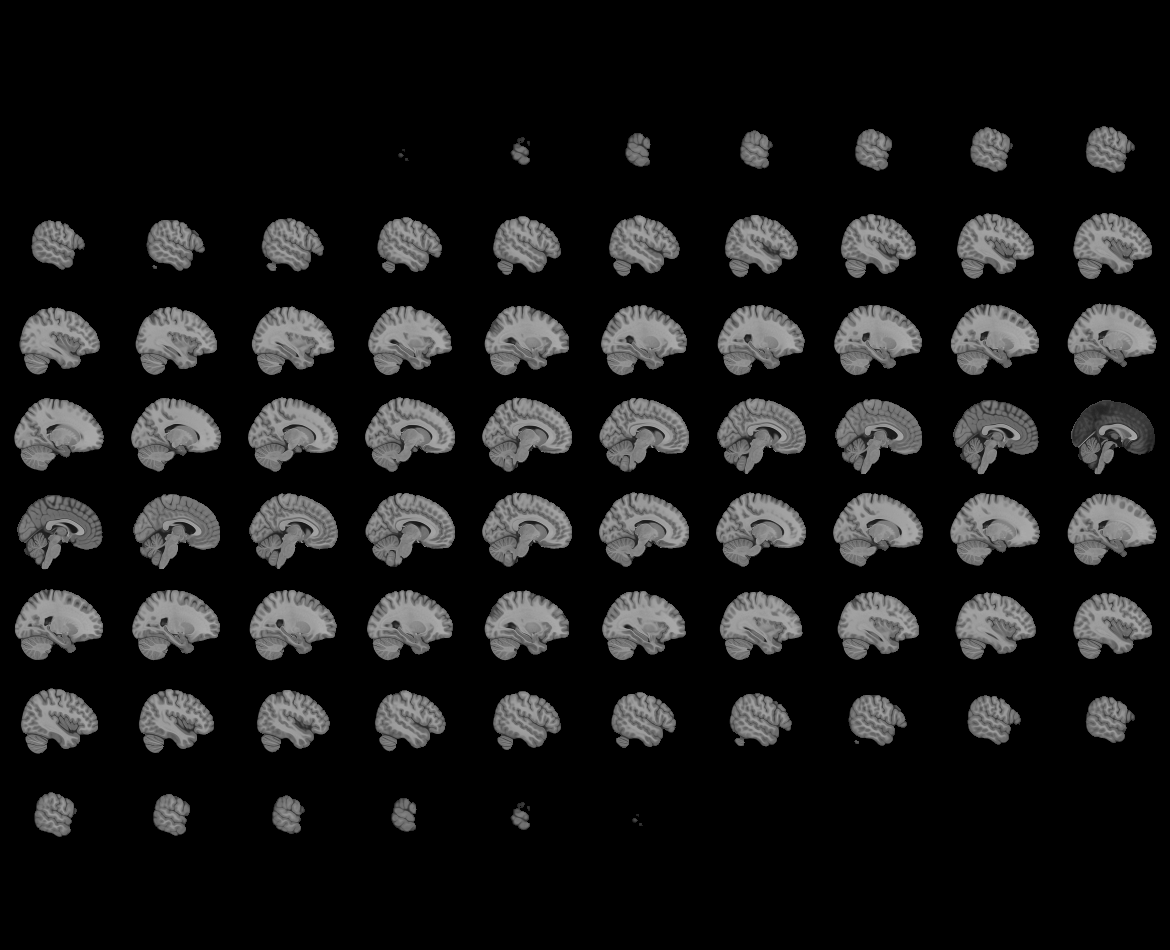
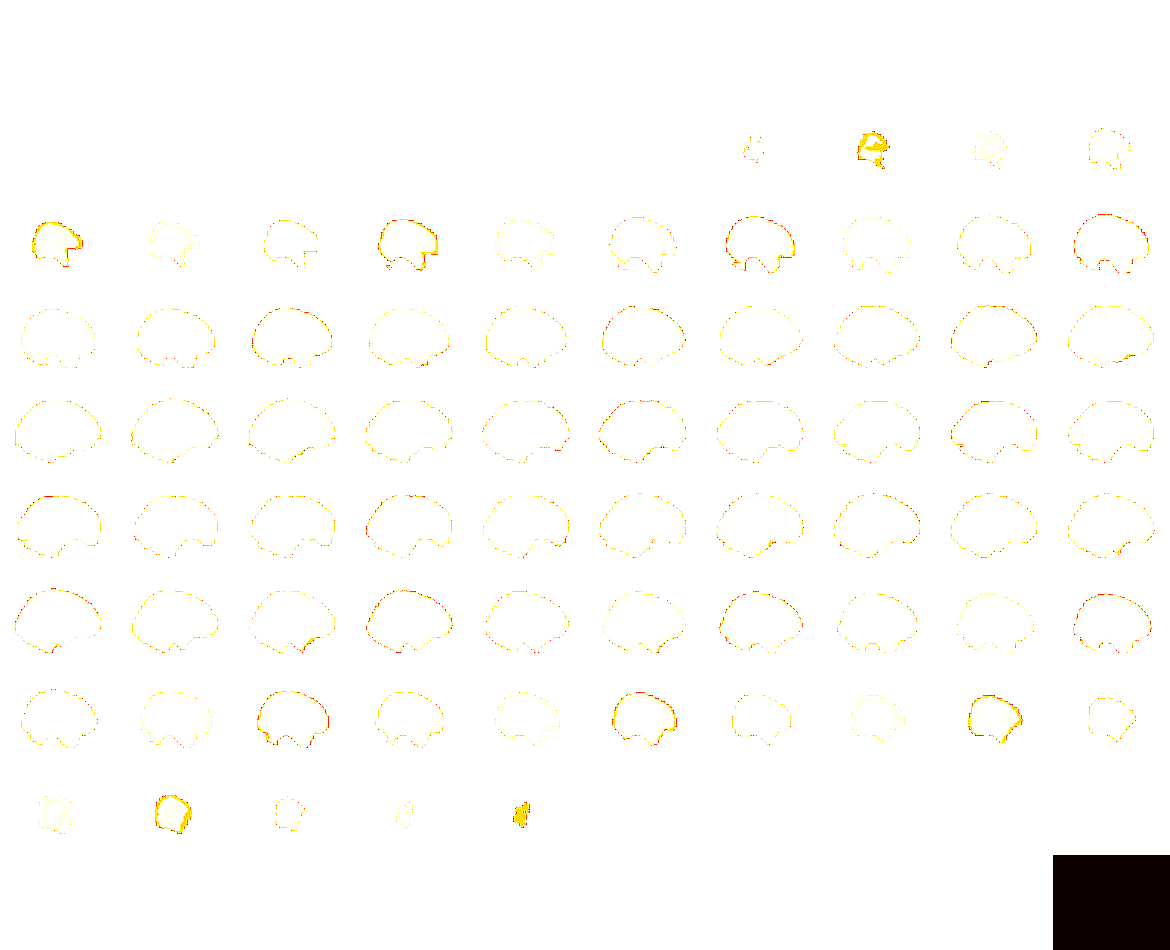

In [524]:
stimuli = ['Pl','Nt','Up']
no_eyeballvoxel_subjects = [4,5,10,11,15,16,17]

sub_mask_list = []
for s, sub in enumerate(no_eyeballvoxel_subjects):

    mask_list = []
    for i, stim in enumerate(stimuli):
        image_path = '../IAPS_fMRI_RSA/fMRI/{}{}.mat'.format(stim,sub-1)
        # load one image to get the dimensions and make the mask
        image_file = sio.loadmat(image_path)
        mask_file = image_file['{}'.format(stim)] #(153594, 100)
        mask_list.append(mask_file)

    allmask = np.hstack(mask_list)
    mask_sum = np.sum(allmask, axis = 1)
    sub_mask_list.append(mask_sum)

allsub_mask = np.vstack(sub_mask_list)
allsub_mask_sum = np.sum(allsub_mask, axis = 0)
mask_flat = (~np.isnan(allsub_mask_sum)).astype(int)
x, y, z = 53,63,46
mask_reshape = mask_flat.reshape(z, y, x)
mask = np.moveaxis(mask_reshape, [0,1,2], [2,1,0])

tmp_image_path = '../IAPS_fMRI_RSA/fMRI/nifti/Nt1.img'
# load one image to get the dimensions and make the mask

tmp_img = nib.load(tmp_image_path)
mask_3d = new_img_like(tmp_img, mask)
view = plotting.view_img(mask_3d)
view

## Create searchlight centers and neighbours

In [526]:
centers, neighbors = get_volume_searchlight(mask, radius=5, threshold=0.5)























































































































































































































































































































































































































































Finding searchlights...: 100%|██████████| 59159/59159 [00:22<00:00, 2576.60it/s]


Found 56949 searchlights


## Load fMRI RDMs

### Stimuli

In [6]:
stim_file = pd.read_csv('../IAPS_fMRI_RSA/fmri_conditions_trial_ordered.csv')
stim_Nt = stim_file[0:100]
stim_Pl = stim_file[100:200].reset_index()
stim_Up = stim_file[200:300].reset_index()

In [7]:
stim_Nt_id = pd.DataFrame(stim_Nt[['category']]).T
stim_Nt_id.shape
stim_Pl_id = pd.DataFrame(stim_Pl[['category']]).T
stim_Pl_id.shape
stim_Up_id = pd.DataFrame(stim_Up[['category']]).T
stim_Up_id.shape
print("Netrual    Type: {} Shape/Length: {}".format(type(stim_Nt_id), stim_Nt_id.shape))
print("Pleasant   Type: {} Shape/Length: {}".format(type(stim_Pl_id), stim_Pl_id.shape))
print("Unpleasant Type: {} Shape/Length: {}".format(type(stim_Up_id), stim_Up_id.shape))

Netrual    Type: <class 'pandas.core.frame.DataFrame'> Shape/Length: (1, 100)
Pleasant   Type: <class 'pandas.core.frame.DataFrame'> Shape/Length: (1, 100)
Unpleasant Type: <class 'pandas.core.frame.DataFrame'> Shape/Length: (1, 100)


In [14]:
allsub_avg = []

subjects = 20
for i in range(subjects):
    sub_avg = []
    #Pleasant
    mat_name_Pl = '../IAPS_fMRI_RSA/fMRI/Pl{}.mat'.format(i+1)
    mat_file_Pl = sio.loadmat(mat_name_Pl)
    data_Pl = mat_file_Pl['Pl'] #(153594, 100)
    data_Pl_reshape = data_Pl.reshape(46, 63, 53, 100)
    data_Pl_reorder = np.moveaxis(data_Pl_reshape, [0,1,2,3], [2,1,0,3])
    data_Pl_reorder_flat = np.reshape(data_Pl_reorder, (153594,100))
    data_Pl_df = pd.DataFrame(data_Pl_reorder_flat) #(153594, 100)
    Pl_df = pd.concat([stim_Pl_id, data_Pl_df]) #(153595,100)
    Pl_df = Pl_df.T

    #Neutral
    mat_name_Nt = '../IAPS_fMRI_RSA/fMRI/Nt{}.mat'.format(i+1)
    mat_file_Nt = sio.loadmat(mat_name_Nt)
    data_Nt = mat_file_Nt['Nt'] #(153594, 100)
    data_Nt_reshape = data_Nt.reshape(46, 63, 53, 100)
    data_Nt_reorder = np.moveaxis(data_Nt_reshape, [0,1,2,3], [2,1,0,3])
    data_Nt_reorder_flat = np.reshape(data_Nt_reorder, (153594,100))
    data_Nt_df = pd.DataFrame(data_Nt_reorder_flat) #(153594, 100)
    Nt_df = pd.concat([stim_Nt_id,data_Nt_df]) #(153595,100)
    Nt_df = Nt_df.T

    #Unpleasant
    mat_name_Up = '../IAPS_fMRI_RSA/fMRI/Up{}.mat'.format(i+1)
    mat_file_Up = sio.loadmat(mat_name_Up)
    data_Up = mat_file_Up['Up'] #(153594, 100)
    data_Up_reshape = data_Up.reshape(46, 63, 53, 100)
    data_Up_reorder = np.moveaxis(data_Up_reshape, [0,1,2,3], [2,1,0,3])
    data_Up_reorder_flat = np.reshape(data_Up_reorder, (153594,100))
    data_Up_df = pd.DataFrame(data_Up_reorder_flat) #(153594, 100)
    Up_df = pd.concat([stim_Up_id, data_Up_df]) #(153595,100)
    Up_df = Up_df.T

    sub_df = pd.concat([Pl_df, Nt_df, Up_df])
    sub_df['category'] = pd.Categorical(sub_df['category'], ["erotic/romance", "happy people", "adventure/nature", "ntr people", "attack", "mutil/disgust" ])
    # sub_df.sort_values(by=['category'])
    sub_avg_df = sub_df.groupby('category').mean() #(1, 153594) 
    sub_avg_df2 = sub_avg_df.reset_index(drop=True) #(3, 153594)

    allsub_avg.append(sub_avg_df2)
    # sub_avg = np.nan_to_num(sub_avg)

In [80]:
allsub_avg[1].shape

(6, 153594)

### Plot one content type out of the six contents 

c:\Users\yujunchen\Anaconda3\envs\neuro\lib\site-packages\nilearn\_utils\niimg.py:63: UserWarning: Non-finite values detected. These values will be replaced with zeros.
  warn(
c:\Users\yujunchen\Anaconda3\envs\neuro\lib\site-packages\numpy\core\fromnumeric.py:758: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)
c:\Users\yujunchen\Anaconda3\envs\neuro\lib\site-packages\nilearn\plotting\html_document.py:59: UserWarning: It seems you have created more than 10 nilearn views. As each view uses dozens of megabytes of RAM, you might want to delete some of them.
  warnings.warn('It seems you have created more than {} '



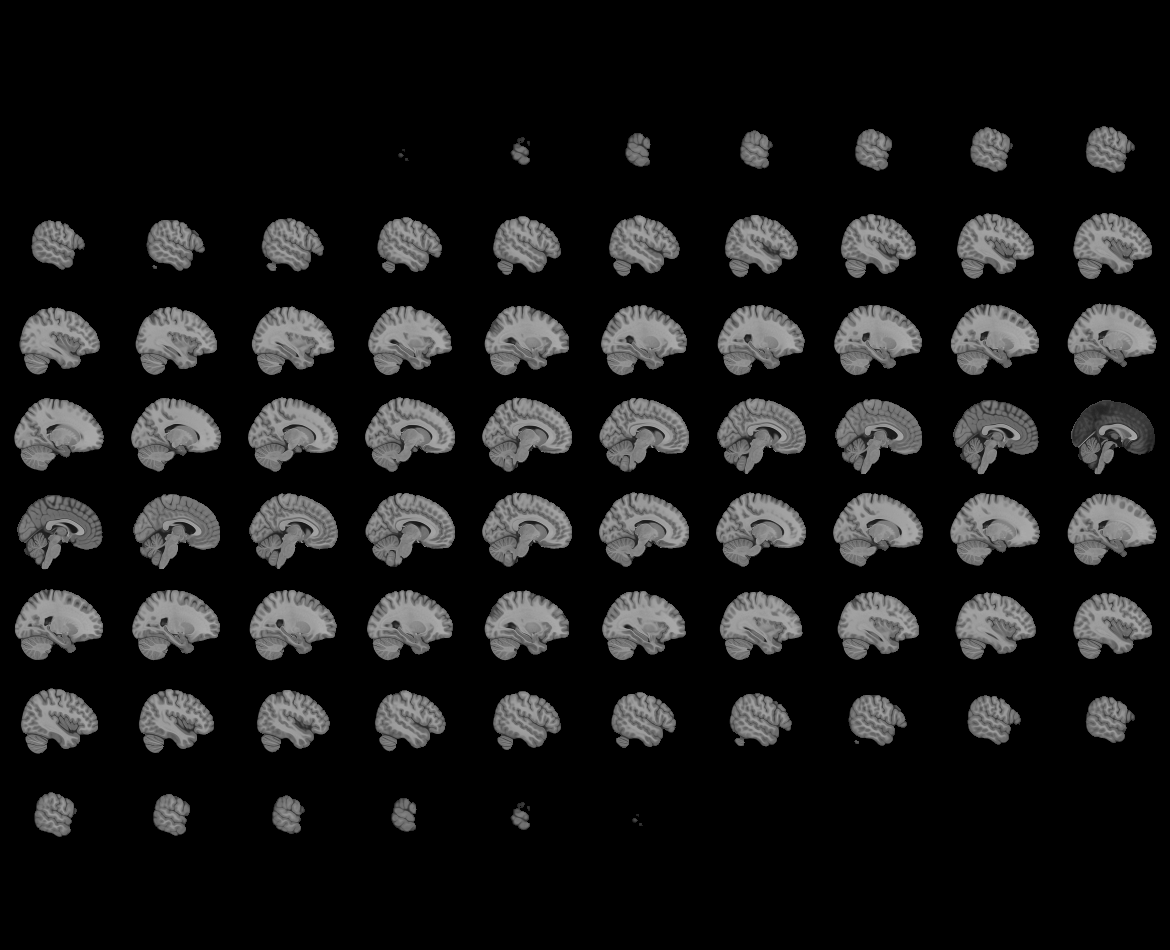
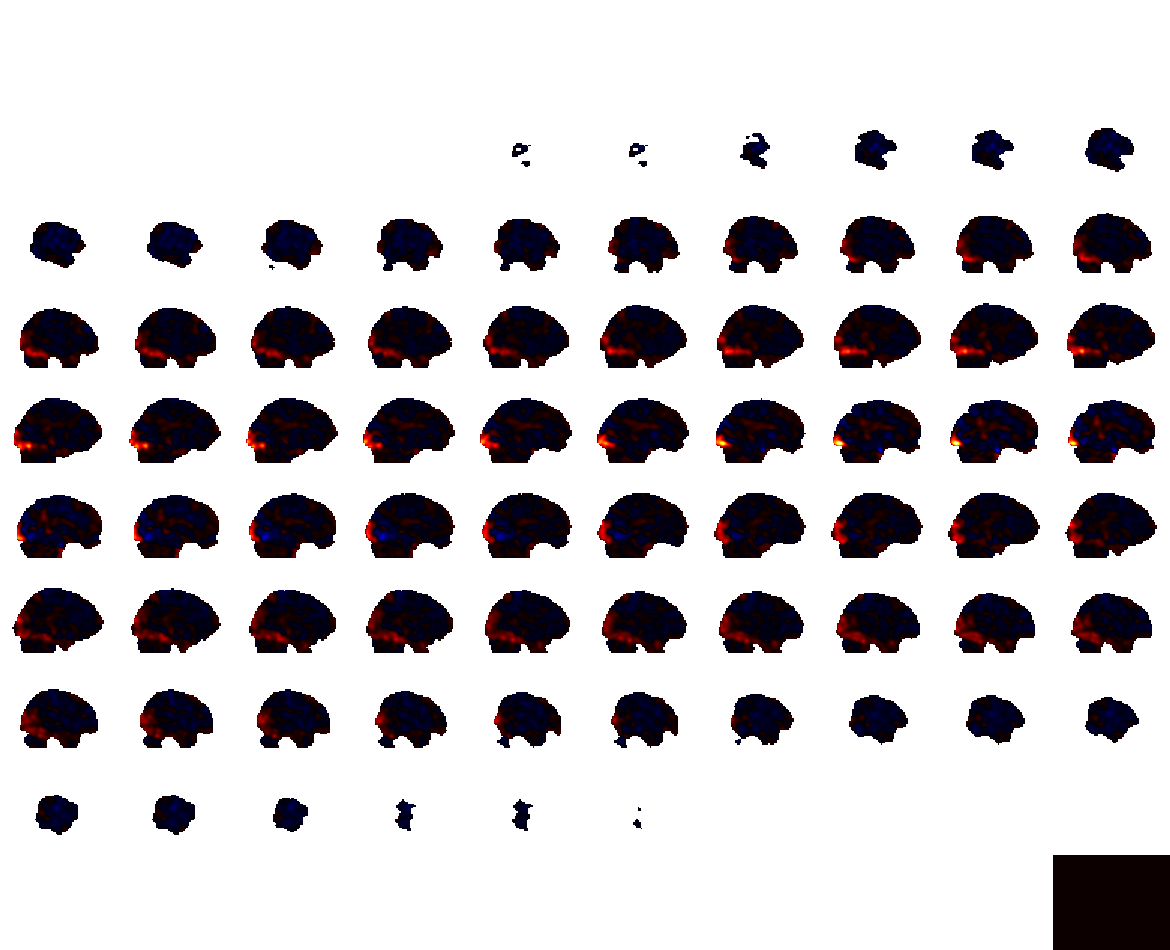

In [411]:
plot_slice = np.array(allsub_avg[4])[1,:]
plot_slice_3d = plot_slice.reshape(53, 63, 46)
plot_neural_rdm_cont1 = new_img_like(tmp_img, plot_slice_3d)
view = plotting.view_img(plot_neural_rdm_cont1)
view

### Plot non-zero voxels by content category

In [317]:
plot_slice = np.array(allsub_avg[3])[5,:]
nonzero_brain_index = np.argwhere(np.array(plot_slice)>0)
# nonzero_brain_index.shape

c:\Users\yujunchen\Anaconda3\envs\neuro\lib\site-packages\numpy\core\fromnumeric.py:758: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)
c:\Users\yujunchen\Anaconda3\envs\neuro\lib\site-packages\nilearn\image\resampling.py:274: UserWarning: Resampling binary images with continuous or linear interpolation. This might lead to unexpected results. You might consider using nearest interpolation instead.
  warnings.warn("Resampling binary images with continuous or "
c:\Users\yujunchen\Anaconda3\envs\neuro\lib\site-packages\nilearn\plotting\html_document.py:59: UserWarning: It seems you have created more than 10 nilearn views. As each view uses dozens of megabytes of RAM, you might want to delete some of them.
  warnings.warn('It seems you have created more than {} '



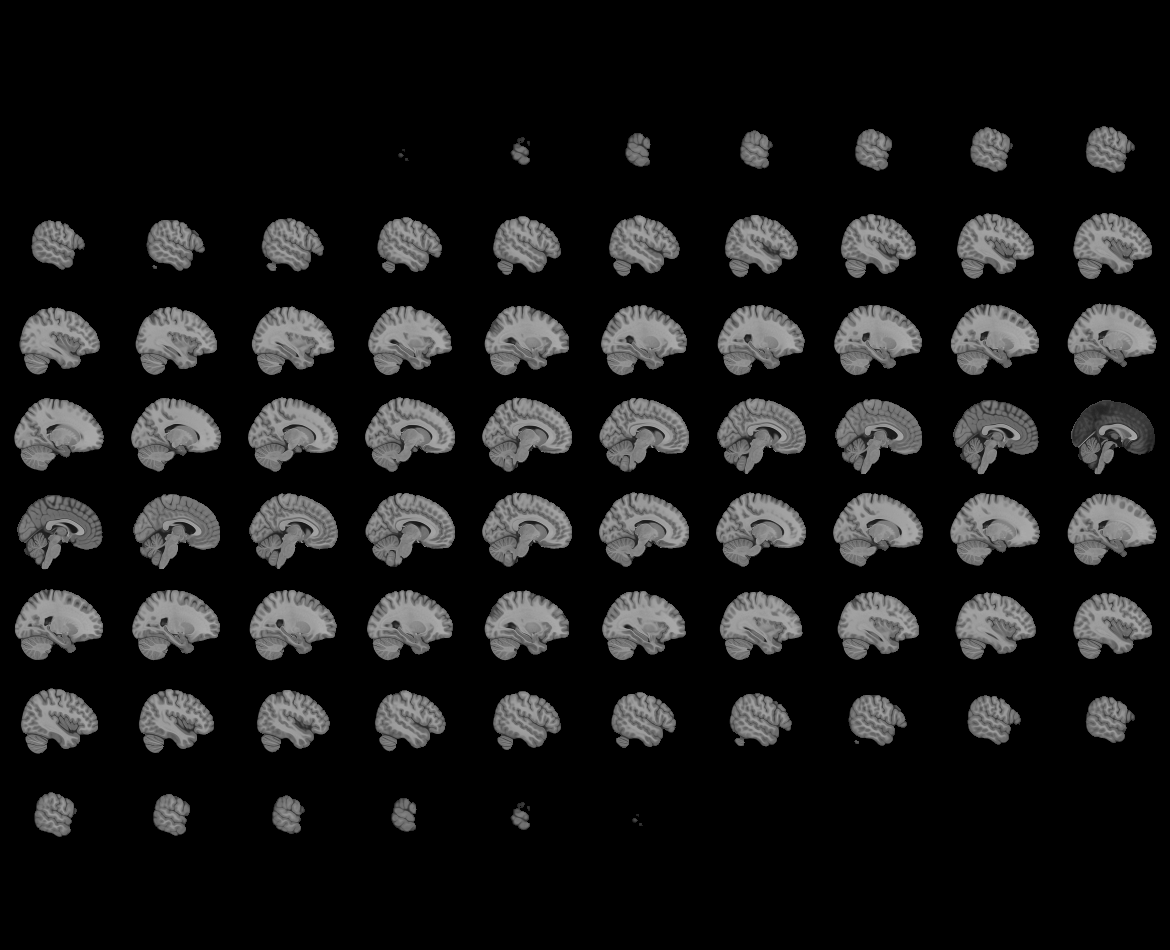
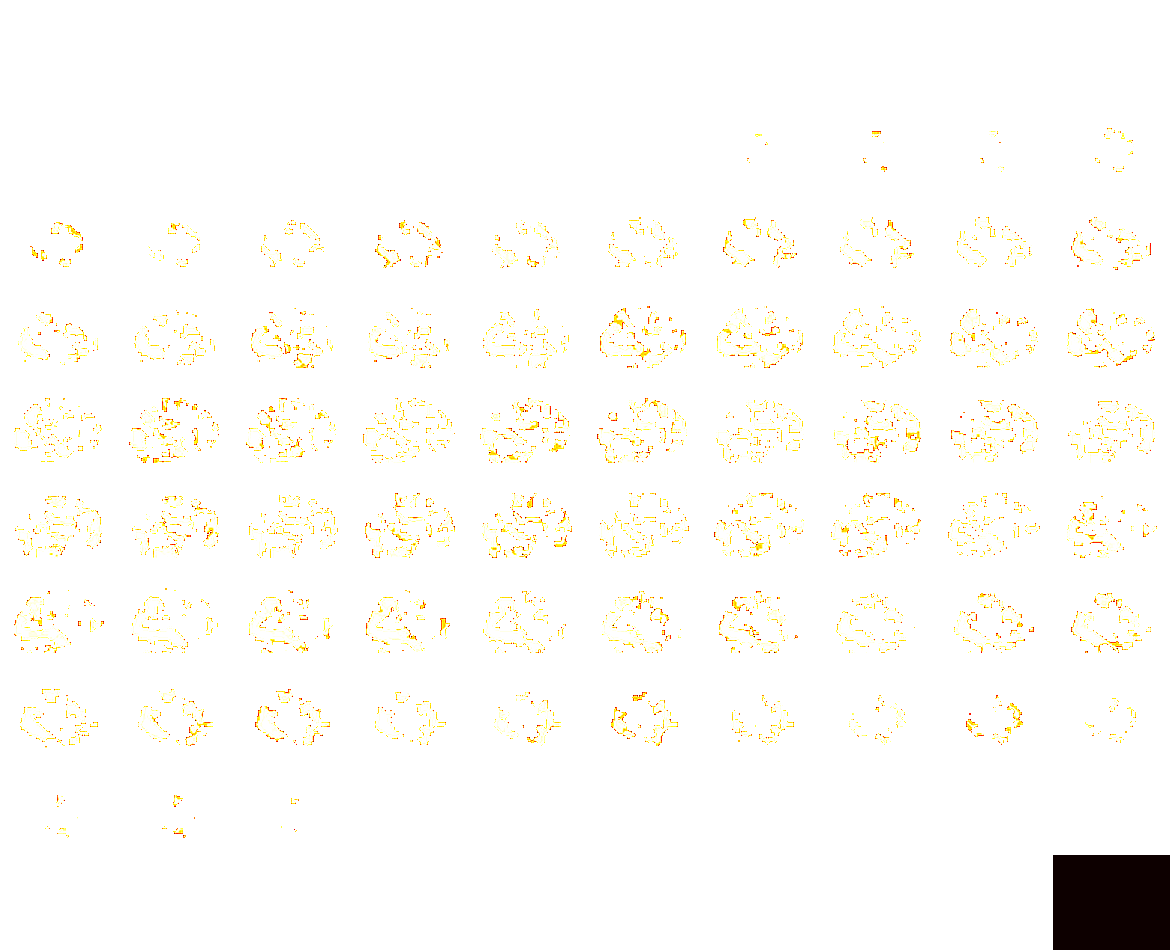

In [318]:
RDM_brain = np.zeros([53*63*46])
RDM_brain[list(nonzero_brain_index)] = 1
RDM_brain = RDM_brain.reshape([53, 63, 46])
plot_nonzero = new_img_like(tmp_img, RDM_brain)
view = plotting.view_img(plot_nonzero)
view

### Export neural RDM

In [15]:
dbfile= open('./outputs/20sub_nerual_6content_rdm2', 'ab')
pickle.dump(allsub_avg, dbfile)                     
dbfile.close()

### Import neural RDM

In [520]:
dbfile = open('./outputs/20sub_nerual_6content_rdm2', 'rb')     
allsub_avg = pickle.load(dbfile)

In [521]:
allsub_avg[1].shape

(6, 153594)

## Load Behavioral RDMs

In [16]:
rdm_behavioral = pd.read_csv("../IAPS_behavioral_RDM/rdm_behavioral_content.csv",  index_col=0)
rdm_behavioral = np.array(rdm_behavioral)
behavioral_model = ModelFixed('Behavioral RDM', upper_tri(rdm_behavioral))

In [517]:
rdm_behavioral.shape

(6, 6)

## Searchlight analysis

In [528]:
eval_score_list = []
RDM_brain_list = []

for i in range(20):
    subj_data = allsub_avg[i]
    subj_data_2d = np.nan_to_num(subj_data)

    image_value = np.arange(6)
    SL_RDM = get_searchlight_RDMs(subj_data_2d, centers, neighbors, image_value, method='correlation', verbose = False)

    eval_results = evaluate_models_searchlight(SL_RDM, behavioral_model, eval_fixed, method='spearman', n_jobs=3)
    # get the evaulation score for each voxel
    # We only have one model, but evaluations returns a list. By using float we just grab the value within that list
    eval_score = [np.float(e.evaluations) for e in eval_results]
    # Create an 3D array, with the size of mask, and
    x, y, z = mask.shape
    RDM_brain = np.zeros([x*y*z])
    RDM_brain[list(SL_RDM.rdm_descriptors['voxel_index'])] = eval_score
    RDM_brain = RDM_brain.reshape([x, y, z])

    eval_score_list.append(eval_score)
    RDM_brain_list.append(RDM_brain)











































































































































































































Calculating RDMs...: 100%|██████████| 100/100 [00:39<00:00,  2.54it/s]
























































































































































































































































































































































































































































































































































































































Evaluating models for each searchlight: 100%|██████████| 56949/56949 [00:43<00:00, 1318.23it/s]
C:\Users\yujunchen\AppData\Loca

In [556]:
SL_RDM.dissimilarities.shape

(56949, 15)

In [579]:
len(eval_score_list[1])

56949

In [578]:
RDM_brain_list[1].shape

(53, 63, 46)

### Investigate NAN searchlight center voxels

In [462]:
subj_data = allsub_avg[14]
subj_data_2d = np.nan_to_num(subj_data)

image_value = np.arange(6)
SL_RDM = get_searchlight_RDMs(subj_data_2d, centers, neighbors, image_value, method='correlation', verbose=False)

































c:\Users\yujunchen\Anaconda3\envs\neuro\lib\site-packages\rsatoolbox\rdm\calc.py:209: RuntimeWarning: invalid value encountered in true_divide
  ma /= np.sqrt(np.einsum('ij,ij->i', ma, ma))[:, None]










































































































































































Calculating RDMs...: 100%|██████████| 100/100 [00:42<00:00,  2.34it/s]


Searchlight whole brain center voxels

In [332]:
# SL_center_voxel = SL_RDM.rdm_descriptors['voxel_index']
# SL_center_voxel[:-10]
# SL_center_voxel.shape # (61997,)

(61997,)

Center voxels index with NAN values in the sphere

In [463]:
rdm_center = SL_RDM.dissimilarities[:,1]
nan_center = np.argwhere(np.isnan(rdm_center)) #nth center, range(53*63*46)

wholebrain_center_voxels = SL_RDM.rdm_descriptors['voxel_index'] # nth brain voxel, range(53*63*46)
nan_brain_center_index = wholebrain_center_voxels[nan_center]

C:\Users\yujunchen\AppData\Local\Temp\ipykernel_16260\2602060957.py:2: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  RDM_nan_brain[[list(nan_brain_center_index)]] = 1
c:\Users\yujunchen\Anaconda3\envs\neuro\lib\site-packages\numpy\core\fromnumeric.py:758: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)
c:\Users\yujunchen\Anaconda3\envs\neuro\lib\site-packages\nilearn\image\resampling.py:274: UserWarning: Resampling binary images with continuous or linear interpolation. This might lead to unexpected results. You might consider using nearest interpolation instead.
  warnings.warn("Resampling binary images with continuous or "
c:\Users\yujunchen\Anaconda3\envs\neuro\lib\site-packages


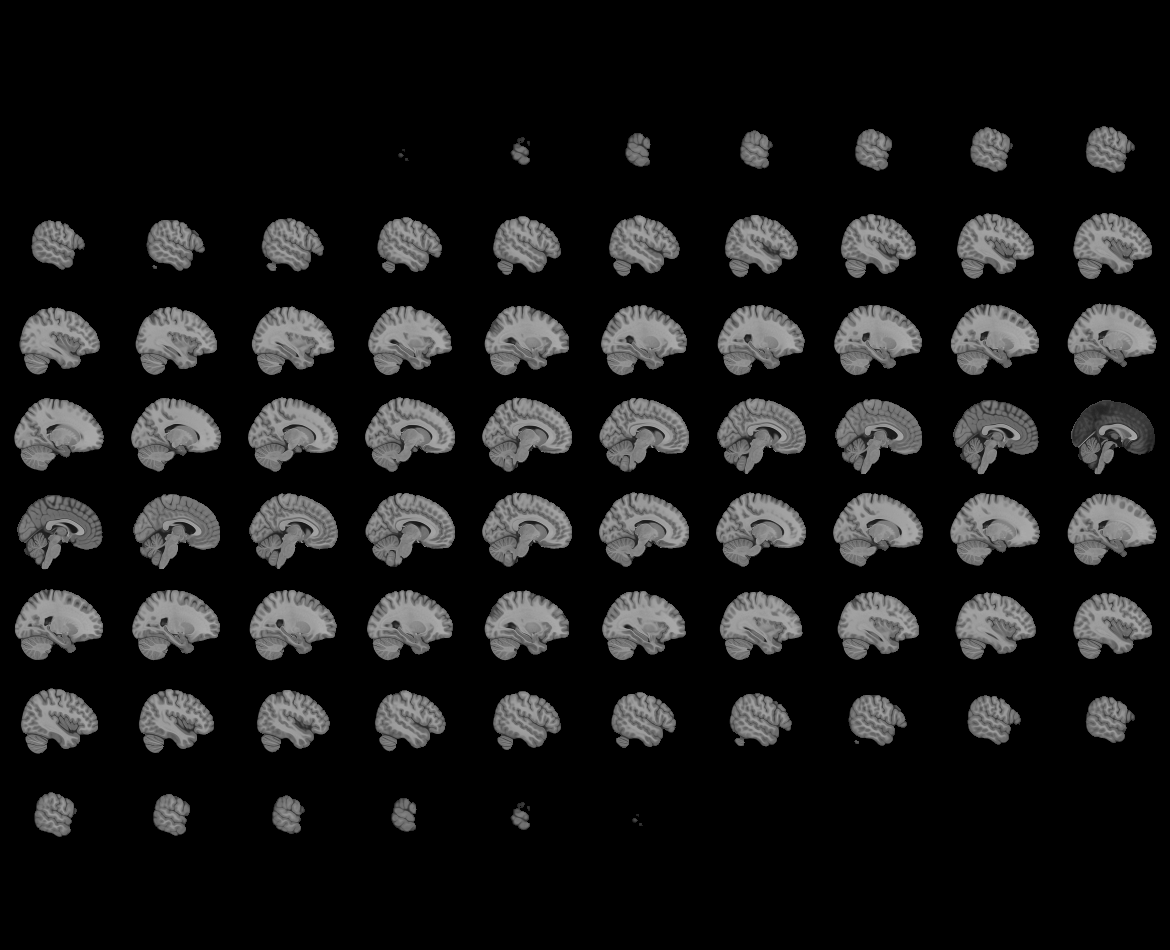
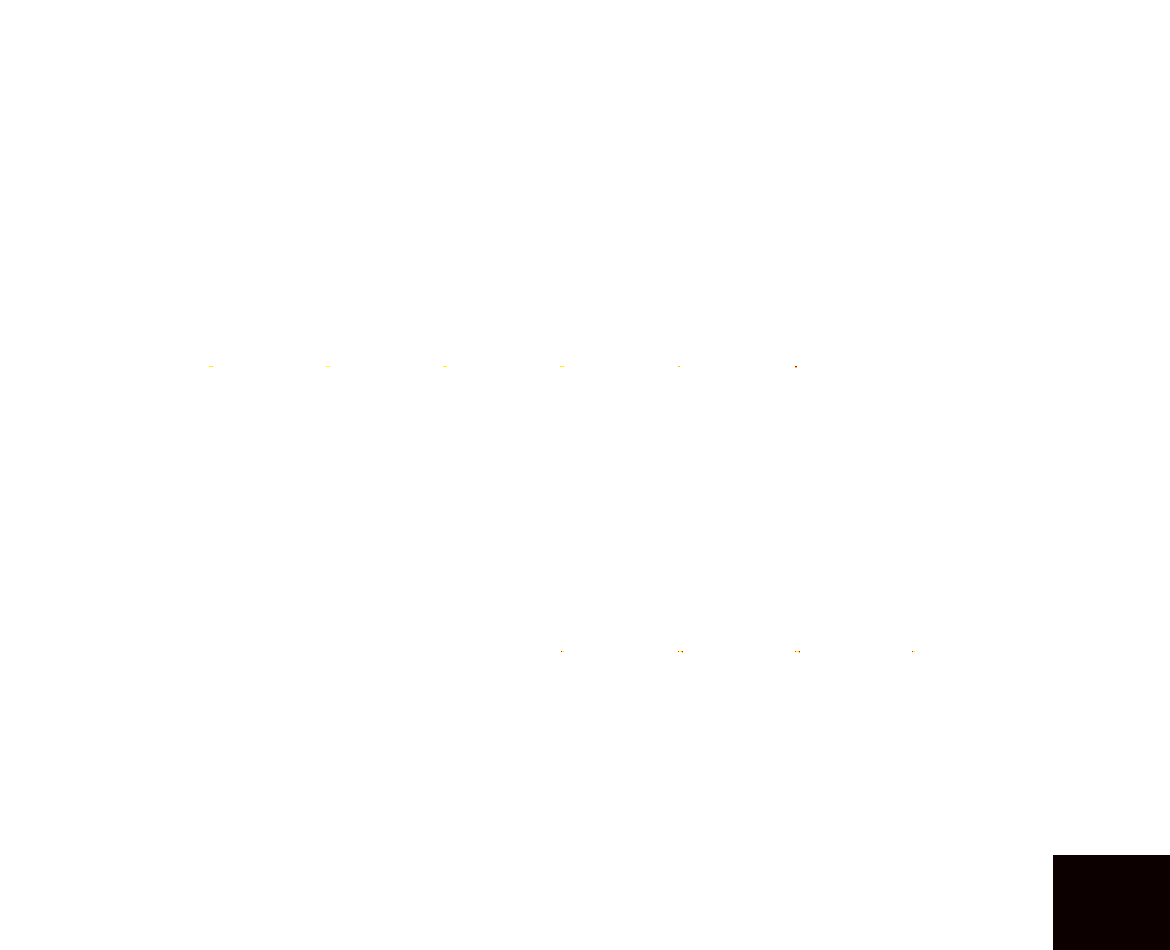

In [465]:
RDM_nan_brain = np.zeros([53*63*46])
RDM_nan_brain[[list(nan_brain_center_index)]] = 1
RDM_nan_brain = RDM_nan_brain.reshape([53, 63, 46])
plot_nan_center = new_img_like(tmp_img, RDM_nan_brain)
view = plotting.view_img(plot_nan_center, verbose = False)
view


In [184]:
# pd.DataFrame(SL_RDM.dissimilarities).to_csv("./tmp/nan_voxel.csv")

Explore the centers with NANs

In [248]:
from rsatoolbox.data.dataset import Dataset
from rsatoolbox.rdm.calc import calc_rdm
import tqdm

image_path = '../IAPS_fMRI_RSA/fMRI/nifti/Nt1.img'
# load one image to get the dimensions and make the mask
tmp_img = nib.load(image_path)
# we infer the mask by looking at non-nan voxels
mask = ~np.isnan(tmp_img.get_fdata())
x, y, z = tmp_img.get_fdata().shape
centers, neighbors = get_volume_searchlight(mask, radius=5, threshold=0.5)

subj_data = allsub_avg[3]
subj_data_2d = np.nan_to_num(subj_data)

image_value = np.arange(6)

events = image_value























































































































































































































































































































































































































































































Finding searchlights...: 100%|██████████| 64544/64544 [00:24<00:00, 2595.04it/s]


Found 61997 searchlights


In [353]:
nan_center[0]

array([9871], dtype=int64)

In [354]:
neighbors[9871]

array([34224, 34225, 34226, 37122, 37123, 37124, 40020, 40021, 40022,
       42918, 42919, 42920, 45816, 45817, 45818, 31372, 31373, 31374,
       34270, 34271, 34272, 34273, 37168, 37169, 37170, 37171, 40066,
       40067, 40068, 40069, 42964, 42965, 42966, 42967, 45862, 45863,
       45864, 45865, 48760, 48761, 48762, 28520, 28521, 28522, 31418,
       31419, 31420, 31421, 34316, 34317, 34318, 34319, 34320, 37214,
       37215, 37216, 37217, 37218, 40112, 40113, 40114, 40115, 40116,
       43010, 43011, 43012, 43013, 43014, 45908, 45909, 45910, 45911,
       45912, 48806, 48807, 48808, 48809, 51704, 51705, 51706, 28566,
       28567, 28568, 31464, 31465, 31466, 31467, 34362, 34363, 34364,
       34365, 34366, 37260, 37261, 37262, 37263, 37264, 40158, 40159,
       40160, 40161, 40162, 43056, 43057, 43058, 43059, 43060, 45954,
       45955, 45956, 45957, 45958, 48852, 48853, 48854, 48855, 51750,
       51751, 51752, 28612, 28613, 28614, 31510, 31511, 31512, 31513,
       34408, 34409,

In [359]:
## get_searchlight_RDMs()
data_2d = np.array(subj_data_2d)
center_data = []
center = centers[9871] 
nb = neighbors[9871]
ds = Dataset(data_2d[:, nb],
                         descriptors={'center': 9871},
                         obs_descriptors={'events': events},
                         channel_descriptors={'voxels': nb})
center_data.append(ds)
RDM = calc_rdm(center_data, method='correlation',
                       descriptor='events').dissimilarities

In [360]:
RDM

array([[nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
        nan, nan]])

In [364]:
nb = neighbors[9871]
data_2d[:, nb]

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

### Export/Load searchlight results

In [529]:
# Export
# Save the evaluation scores and RDMs.

pd.DataFrame(eval_score_list).to_csv("./outputs/20sub_SL_eval_score_6content.csv")
dbfile= open('./outputs/20sub_SL_rdm_brain_6content', 'ab')
pickle.dump(RDM_brain_list, dbfile)                     
dbfile.close()


In [ ]:
# Import
eval_score_df = pd.read_csv("./outputs/20sub_SL_eval_score_6content.csv")
eval_score_list = eval_score_df.values.tolist()
dbfile = open('./outputs/20sub_SL_rdm_brain_6content', 'rb')     
RDM_brain_list = pickle.load(dbfile)

In [576]:
eval_score_list[1][1]

0.1964285714285714

## Plot results

In [ ]:
sns.displot(eval_score_list[1])
plt.title('Distributions of correlations', size=18)
plt.ylabel('Occurance', size=18)
plt.xlabel('Spearmann correlation', size=18)
sns.despine()
plt.show()

In [ ]:
# lets plot the voxels above the 99th percentile
threshold = np.percentile(eval_score_list[4], 99)
plot_img = new_img_like(tmp_img, RDM_brain_list[4])
cmap = RDMcolormapObject()
coords = range(-100, 100, 5)


In [ ]:
fig_x = plt.figure(figsize=(30, 3))
display_x = plotting.plot_stat_map(
        plot_img, colorbar=True, cut_coords=coords,threshold=threshold,
        display_mode='x', draw_cross=False, figure=fig_x,
        title=f'Behavioral model evaluation', cmap=cmap,
        black_bg=False, annotate=False)

fig_y = plt.figure(figsize=(30, 3))
display_y = plotting.plot_stat_map(
        plot_img, colorbar=True, cut_coords=coords,threshold=threshold,
        display_mode='y', draw_cross=False, figure=fig_y,
        title=f'Behavioral model evaluation', cmap=cmap,
        black_bg=False, annotate=False)

fig_z = plt.figure(figsize=(30, 3))        
display_z = plotting.plot_stat_map(
        plot_img, colorbar=True, cut_coords=coords,threshold=threshold,
        display_mode='z', draw_cross=False, figure=fig_z,
        title=f'Behavioral model evaluation', cmap=cmap,
        black_bg=False, annotate=False)

# # Create new figure and three subplots, sharing axes
# fig3, (ax1, ax2, ax3) = plt.subplots(3,1,sharey=True, sharex=True,figsize=(60,12))        
# fig3.show()
plt.show()

In [573]:
RDM_brain_list[1].shape

(53, 63, 46)

## Across subjects plot

In [530]:
for i in range(20):
    sl_max = np.max(RDM_brain_list[i])
    sl_min = np.min(RDM_brain_list[i])
    sl_mid = np.median(RDM_brain_list[i])
    print("Subject{} max:{}, mid:{}, min:{}".format(i+1,sl_max,sl_mid, sl_min ))

Subject1 max:0.8785714285714286, mid:0.0, min:-0.6892857142857143
Subject2 max:0.9285714285714285, mid:0.0, min:-0.6714285714285714
Subject3 max:0.8571428571428571, mid:0.0, min:-0.625
Subject4 max:0.8607142857142858, mid:0.0, min:-0.6857142857142856
Subject5 max:0.9357142857142857, mid:0.0, min:-0.807142857142857
Subject6 max:0.9714285714285715, mid:0.0, min:-0.7571428571428571
Subject7 max:0.8285714285714285, mid:0.0, min:-0.6321428571428571
Subject8 max:0.9178571428571428, mid:0.0, min:-0.7107142857142856
Subject9 max:0.9035714285714286, mid:0.0, min:-0.6357142857142857
Subject10 max:0.8678571428571428, mid:0.0, min:-0.6392857142857142
Subject11 max:0.8928571428571428, mid:0.0, min:-0.6714285714285714
Subject12 max:0.9535714285714285, mid:0.0, min:-0.5964285714285714
Subject13 max:0.9107142857142857, mid:0.0, min:-0.7821428571428571
Subject14 max:0.8785714285714286, mid:0.0, min:-0.75
Subject15 max:0.8678571428571428, mid:0.0, min:-0.6821428571428572
Subject16 max:0.85, mid:0.0, min

In [569]:
RDM_brain_bin_list = []

for i in range(20):
    RDM_brain_bin_thred = np.where(RDM_brain_list[i] > 0.7, 1, 0)
    RDM_brain_bin_list.append(RDM_brain_bin_thred)

In [570]:
for i in range(20):
    sl_max = np.max(RDM_brain_bin_list[i])
    sl_min = np.min(RDM_brain_bin_list[i])
    print("Subject{} max:{}, min:{}".format(i+1,sl_max,sl_min ))

Subject1 max:1, min:0
Subject2 max:1, min:0
Subject3 max:1, min:0
Subject4 max:1, min:0
Subject5 max:1, min:0
Subject6 max:1, min:0
Subject7 max:1, min:0
Subject8 max:1, min:0
Subject9 max:1, min:0
Subject10 max:1, min:0
Subject11 max:1, min:0
Subject12 max:1, min:0
Subject13 max:1, min:0
Subject14 max:1, min:0
Subject15 max:1, min:0
Subject16 max:1, min:0
Subject17 max:1, min:0
Subject18 max:1, min:0
Subject19 max:1, min:0
Subject20 max:1, min:0


In [571]:
RDM_brain_bin_array = np.stack(RDM_brain_bin_list, axis=0)
# RDM_brain_bin_array.shape
SL_threshcount = np.sum(RDM_brain_bin_array, axis = 0)
sl_bin_max = np.max(SL_threshcount)
sl_bin_min = np.min(SL_threshcount)
print("max:{}, min:{}".format(sl_bin_max,sl_bin_min ))

max:4, min:0


c:\Users\yujunchen\Anaconda3\envs\neuro\lib\site-packages\numpy\core\fromnumeric.py:758: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)
c:\Users\yujunchen\Anaconda3\envs\neuro\lib\site-packages\nilearn\image\resampling.py:545: UserWarning: Casting data from int32 to float32
  warnings.warn("Casting data from %s to %s" % (data.dtype.name, aux))
c:\Users\yujunchen\Anaconda3\envs\neuro\lib\site-packages\nilearn\plotting\html_document.py:59: UserWarning: It seems you have created more than 10 nilearn views. As each view uses dozens of megabytes of RAM, you might want to delete some of them.
  warnings.warn('It seems you have created more than {} '



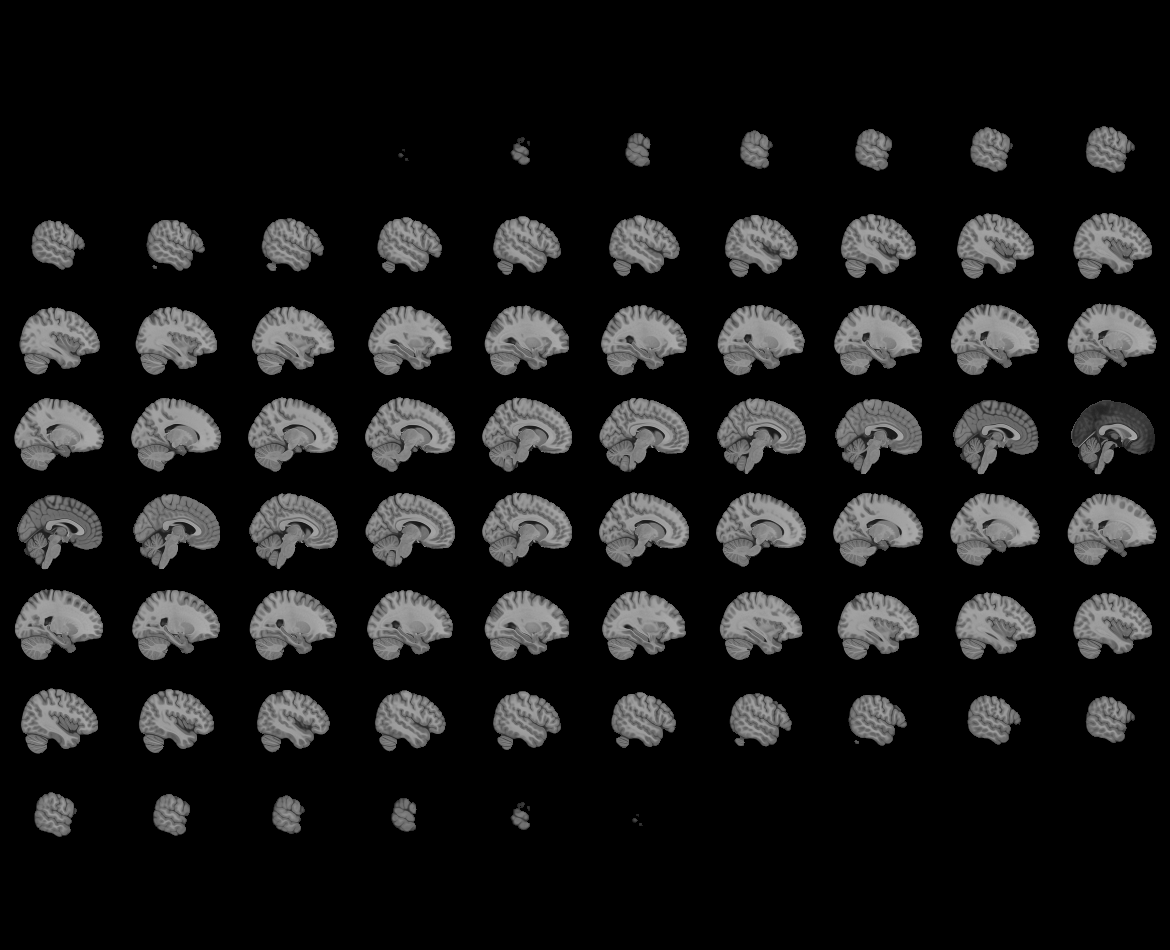
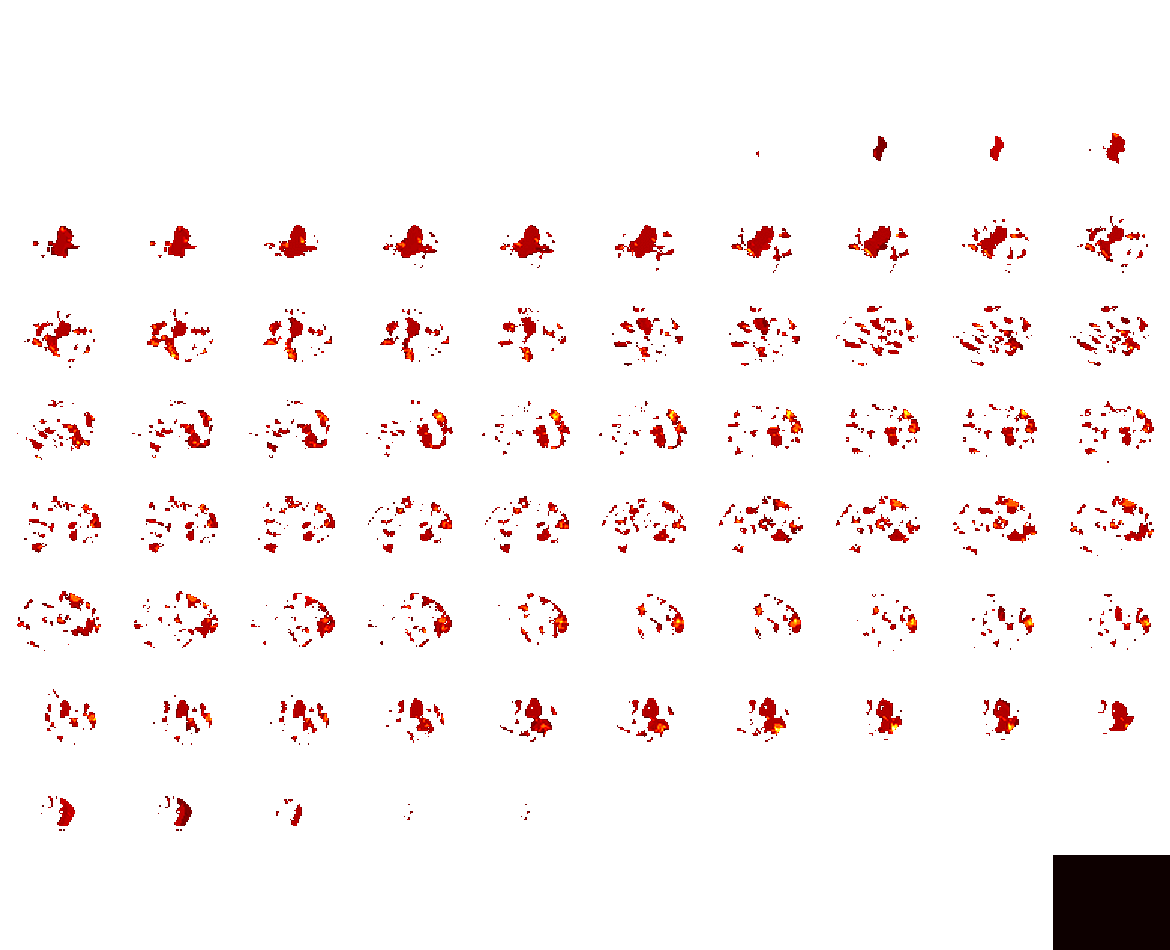

In [572]:
plot_SL_img = new_img_like(tmp_img, SL_threshcount)
view = plotting.view_img(plot_SL_img)
view

## Group analysis
When these results are used for group analysis across multiple subjects, it may be good to Fisher-transform the correlation values, so that they are more normally distributed.

### Fisher z transformation

In [583]:
eval_score_array = np.array(eval_score_list)

In [596]:
eval_score_array[:,1]

array([ 0.16785714,  0.19642857,  0.10714286, -0.09642857,  0.15357143,
       -0.36071429, -0.24285714, -0.28214286, -0.07857143, -0.01071429,
       -0.22142857, -0.2       , -0.16785714,  0.23571429, -0.28571429,
        0.63571429, -0.37142857, -0.24285714,  0.00357143, -0.28571429])

In [588]:
seed_to_voxel_correlations_fisher_z = np.arctanh(eval_score_array)

In [589]:
seed_to_voxel_correlations_fisher_z.shape

(20, 56949)

In [597]:
seed_to_voxel_correlations_fisher_z[:,1]

array([ 0.16946086,  0.19901506,  0.10755569, -0.09672913,  0.15479609,
       -0.37770678, -0.2478081 , -0.29000874, -0.07873372, -0.0107147 ,
       -0.22515784, -0.20273255, -0.16946086,  0.24023138, -0.29389333,
        0.75094819, -0.39007928, -0.2478081 ,  0.00357144, -0.29389333])

### t-test

In [601]:
seed_to_voxel_correlations_fisher_z.shape[-1]

56949

In [610]:
t_stat_list = []
p_value_list = []

for i in range(seed_to_voxel_correlations_fisher_z.shape[-1]):
    t_statistic, p_value = stats.ttest_1samp(a=seed_to_voxel_correlations_fisher_z[:,i], popmean=0) 
    t_stat_list.append(t_statistic)
    p_value_list.append(p_value)

t_stat_array = np.array(t_stat_list)
p_value_array = np.array(p_value_list)

In [644]:
x, y, z = mask.shape
p_value_brain = np.empty([x*y*z])
p_value_brain[list(SL_RDM.rdm_descriptors['voxel_index'])] = p_value_array
neg_log_p = np.log10(p_value_brain) * (-1)
neg_log_p_brain = neg_log_p.reshape([x, y, z])

C:\Users\yujunchen\AppData\Local\Temp\ipykernel_16260\398630080.py:4: RuntimeWarning: divide by zero encountered in log10
  neg_log_p = np.log10(p_value_brain) * (-1)


c:\Users\yujunchen\Anaconda3\envs\neuro\lib\site-packages\nilearn\_utils\niimg.py:63: UserWarning: Non-finite values detected. These values will be replaced with zeros.
  warn(
c:\Users\yujunchen\Anaconda3\envs\neuro\lib\site-packages\numpy\core\fromnumeric.py:758: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)
c:\Users\yujunchen\Anaconda3\envs\neuro\lib\site-packages\nilearn\plotting\html_document.py:59: UserWarning: It seems you have created more than 10 nilearn views. As each view uses dozens of megabytes of RAM, you might want to delete some of them.
  warnings.warn('It seems you have created more than {} '



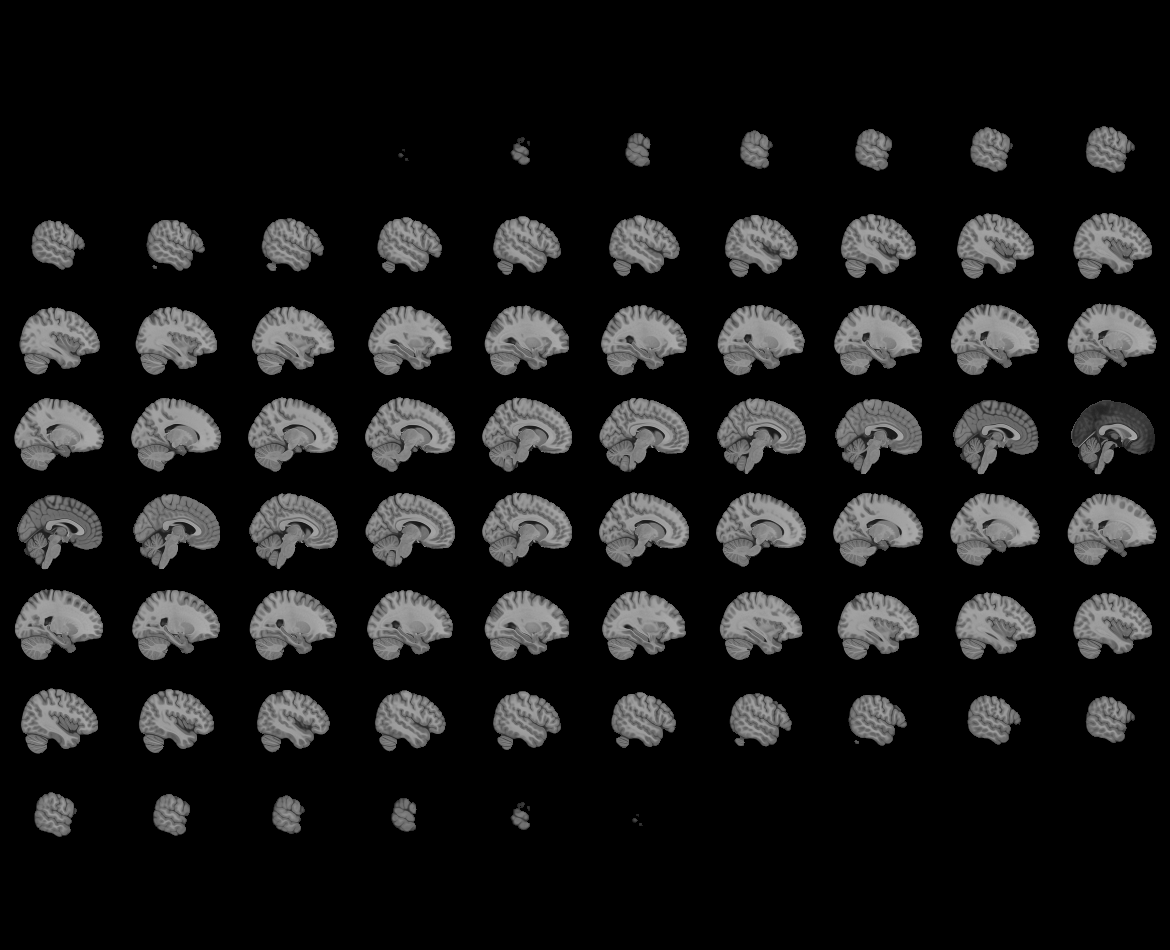
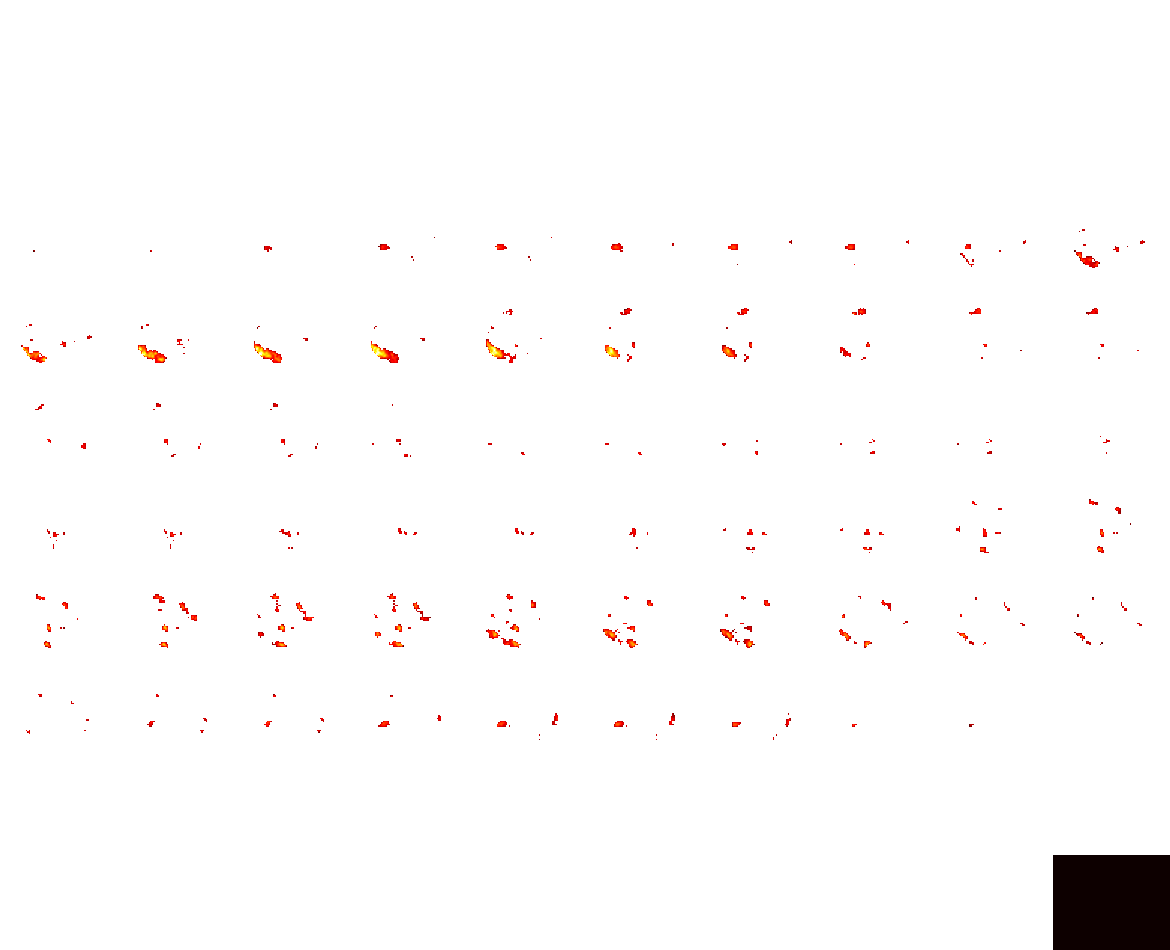

In [650]:
plot_neglog_p_img = new_img_like(tmp_img, neg_log_p_brain)
view = plotting.view_img(plot_neglog_p_img, threshold = 2)
view

### Corrected p-values

In [649]:
reject_decision, corrected_pvalue = fdrcorrection(p_value_array, alpha=0.001, method='indep', is_sorted=False)

In [652]:
x, y, z = mask.shape
corrected_p_value_array = np.empty([x*y*z])
corrected_p_value_array[list(SL_RDM.rdm_descriptors['voxel_index'])] = corrected_pvalue
neg_log_corrected_p = np.log10(corrected_p_value_array) * (-1)
neg_log_corrected_p_brain = neg_log_corrected_p.reshape([x, y, z])

C:\Users\yujunchen\AppData\Local\Temp\ipykernel_16260\2821812379.py:4: RuntimeWarning: divide by zero encountered in log10
  neg_log_corrected_p = np.log10(corrected_p_value_array) * (-1)


c:\Users\yujunchen\Anaconda3\envs\neuro\lib\site-packages\nilearn\_utils\niimg.py:63: UserWarning: Non-finite values detected. These values will be replaced with zeros.
  warn(
c:\Users\yujunchen\Anaconda3\envs\neuro\lib\site-packages\numpy\core\fromnumeric.py:758: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)
c:\Users\yujunchen\Anaconda3\envs\neuro\lib\site-packages\nilearn\plotting\html_document.py:59: UserWarning: It seems you have created more than 10 nilearn views. As each view uses dozens of megabytes of RAM, you might want to delete some of them.
  warnings.warn('It seems you have created more than {} '



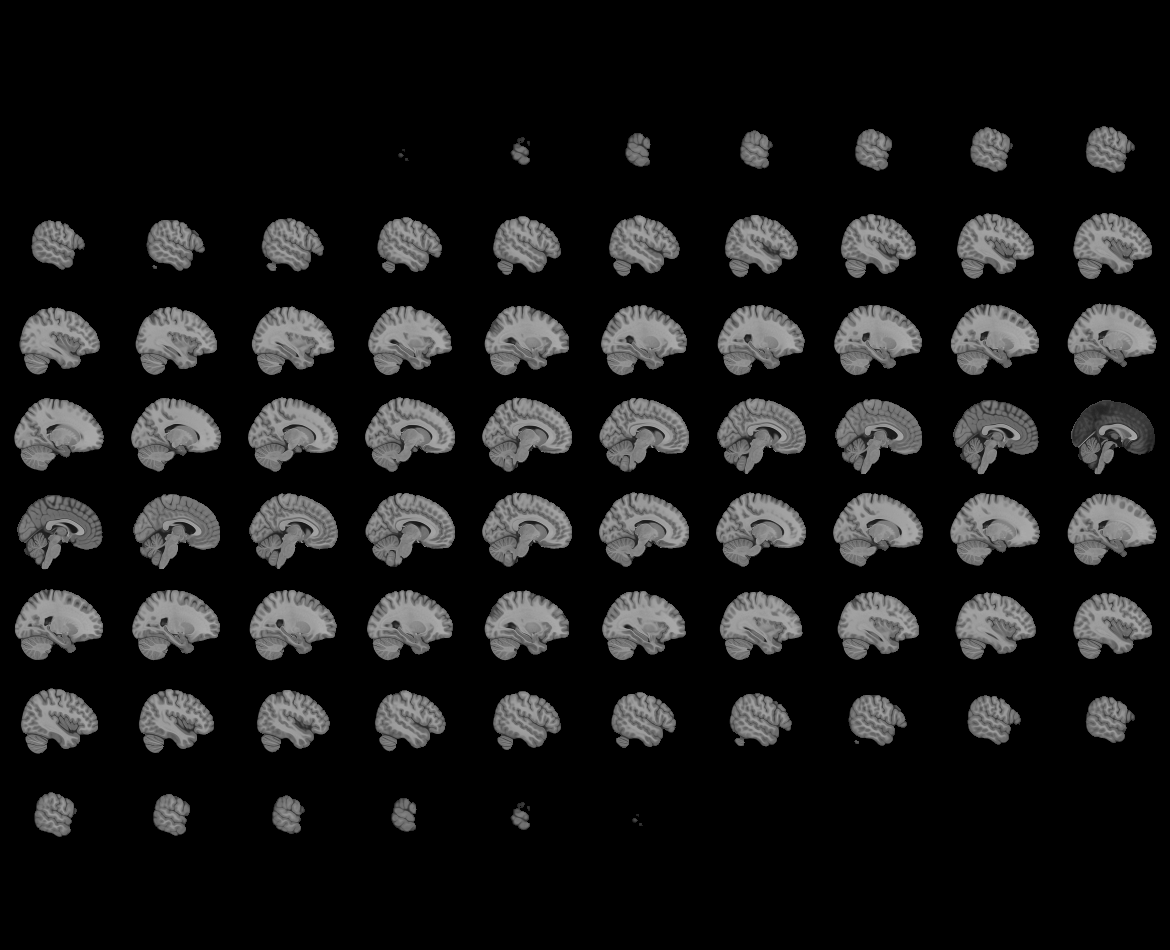
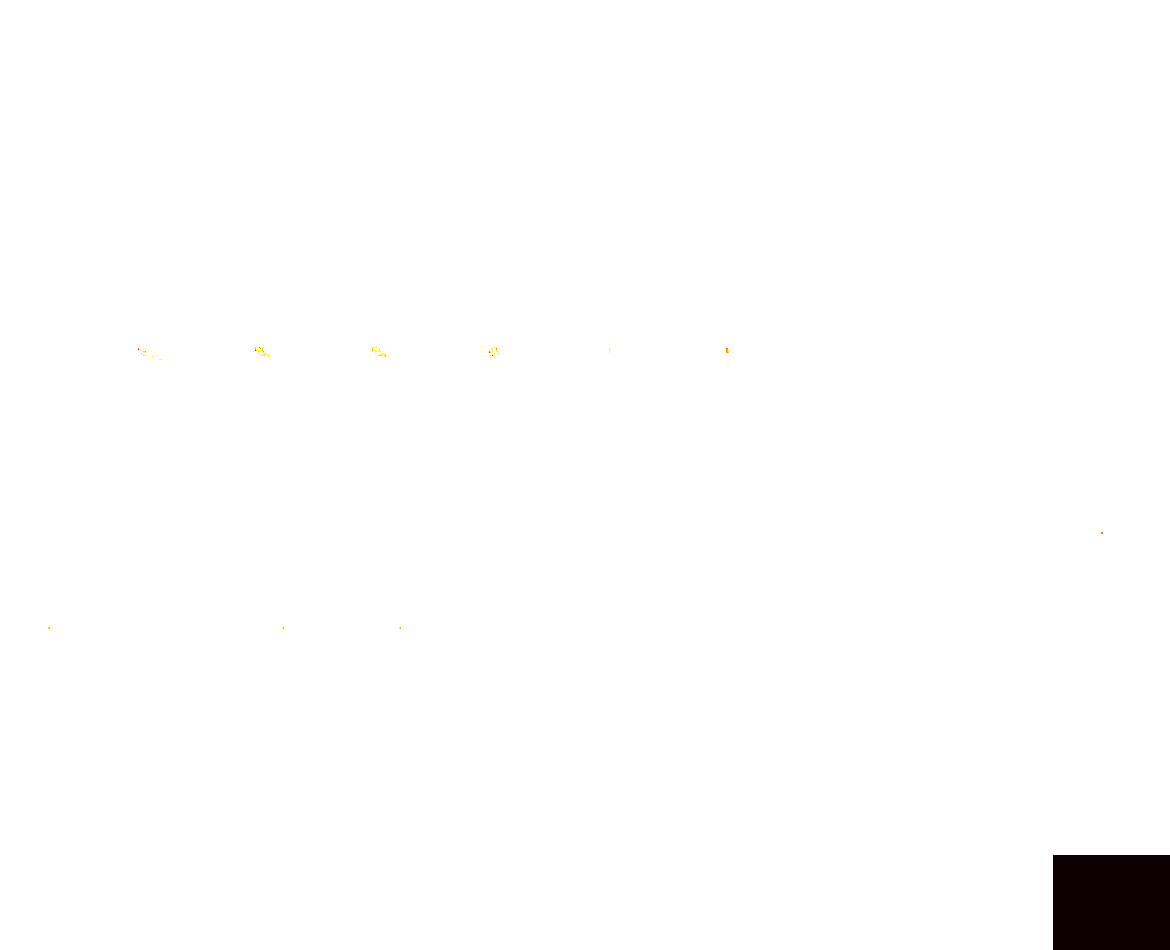

In [653]:
plot_corrected_neglog_pvalue_img = new_img_like(tmp_img, neg_log_corrected_p_brain)
view = plotting.view_img(plot_corrected_neglog_pvalue_img, threshold = 2)
view

In [654]:
nib.save(plot_corrected_neglog_pvalue_img, os.path.join("C:/Users/yujunchen/Dropbox (UFL)/Searchlight results", 'beh6.nii.gz'))